In [33]:
# sanity checks
import sys, platform, pkgutil
import pandas as pd
print("Python:", sys.executable)
print("Version:", platform.python_version())
print("xarray installed?", pkgutil.find_loader("xarray") is not None)

Python: /Users/vb/Desktop/VBThesisCode2_FastAPI/.venv/bin/python
Version: 3.11.11
xarray installed? True


In [43]:
import xarray as xr
#  path for the NetCDF file downloaded from Davis weather station data at Green Village
nc_path = "../input/ExternalTemp/davis-TUD-GV_Green_Village_202504.nc"

ds = xr.open_dataset(nc_path)
ds  # print a summary: dimensions, coords, data_vars, attributes

<xarray.Dataset> Size: 5MB
Dimensions:                   (time: 41046)
Dimensions without coordinates: time
Data variables: (12/16)
    epoch_time                (time) int32 164kB ...
    time_as_string            (time) <U19 3MB ...
    latitude                  float32 4B ...
    longitude                 float32 4B ...
    altitude                  float32 4B ...
    pressure                  (time) float32 164kB ...
    ...                        ...
    rain_rate                 (time) float32 164kB ...
    UV_radiation              (time) float32 164kB ...
    wind_speed                (time) float32 164kB ...
    wind_to_direction         (time) float32 164kB ...
    wind_gust_speed           (time) float32 164kB ...
    wind_gust_from_direction  (time) float32 164kB ...
Attributes:
    title:         weather station data
    institution:   Delft University of Technology
    source:        surface observation
    history:       produced on 2025-06-06 by Marc Schleiss
    sensor_type:   Davis Vantage Pro2
    site_name:     Green_Village
    sensor_name:   davis-TUD-GV
    project_name:  Rotterdam Atmospheric Measurement Network (RAMN), Ruisdael...
    url:           https://ruisdael-observatory.nl/
    contributors:  Marc Schleiss, Mahaut Sourzac, Marjolein van Esch, Jelle B...
    data_license:  CC BY 4.0 https://creativecommons.org/licenses/by-sa/4.0/

In [44]:
# List variables & attributes - to find temperature name/units
print("Variables:", list(ds.data_vars))
for v in ds.data_vars:
    print(f"\n[{v}]")
    for k, val in ds[v].attrs.items():
        print(f"  {k}: {val}")

Variables: ['epoch_time', 'time_as_string', 'latitude', 'longitude', 'altitude', 'pressure', 'temperature', 'humidity', 'solar_irradiance', 'rain', 'rain_rate', 'UV_radiation', 'wind_speed', 'wind_to_direction', 'wind_gust_speed', 'wind_gust_from_direction']

[epoch_time]
  long_name: End time of observation period, in seconds since 1970-01-01 00:00:00 UTC
  units: s
  comment: The length of a measurement interval is 1 minute. Values are rounded to the nearest integer.

[time_as_string]
  long_name: End time of observation period in YYYY-MM-DD HH:MM:SS UTC
  units: 
  comment: This is the same as epoch_time but in human readable format.

[latitude]
  long_name: latitude of site
  units: degree_north

[longitude]
  long_name: longitude of site
  units: degree_east

[altitude]
  long_name: altitude of site
  units: m

[pressure]
  long_name: atmospheric pressure
  units: mbar
  comment: inside the console

[temperature]
  long_name: air temperature
  units: °C
  comment: outside, within 

In [45]:
# Convert to a tidy DataFrame and preview
df = ds.to_dataframe().reset_index()
df.head()
# df.columns

,time,epoch_time,time_as_string,latitude,longitude,altitude,pressure,temperature,humidity,solar_irradiance,rain,rain_rate,UV_radiation,wind_speed,wind_to_direction,wind_gust_speed,wind_gust_from_direction
0,0,1743465600,2025-04-01,51.996109,4.378741,2.0,1029.394287,5.22,86.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN
1,1,1743465660,2025-04-01 00:01:00,51.996109,4.378741,2.0,1029.428101,5.22,86.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN
2,2,1743465720,2025-04-01 00:02:00,51.996109,4.378741,2.0,1029.394287,5.17,86.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN
3,3,1743465780,2025-04-01 00:03:00,51.996109,4.378741,2.0,1029.394287,5.17,86.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN
4,4,1743465840,2025-04-01 00:04:00,51.996109,4.378741,2.0,1029.428101,5.17,86.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN


In [46]:

# non-NaN temperature values
non_nan_count = df['temperature'].notna().sum()
print(f"Non-NaN temperature values: {non_nan_count}")

# show total rows and percentage
total_rows = len(df)
percentage = (non_nan_count / total_rows) * 100
print(f"Total rows: {total_rows}, Percentage non-NaN: {percentage:.2f}%")

Non-NaN temperature values: 41046
Total rows: 41046, Percentage non-NaN: 100.00%


### Creating a new dataframe that has columns - 
1. pressure, 
2. temperature, 
3. humidity, 
4. solar_irradiance, 
5. wind_speed. 
##### For each of these columns, storing only one value per hour. 
For Jan 2025 data - the 'time_as_string' column has 31 NaN values in 43201. Not a big problem but epoch time has been used instead (since that has no NaN values)
epoch_time values are Unix seconds (increments of 60 = 1‑minute steps), so we should convert with unit='s'

In [47]:
# CONVERTING epoch_time to datetime format
# REASON - df.resample('1h') only works if the DataFrame’s index is a DatetimeIndex — so setting it IS essential before time-based grouping

# --- 1) Build a UTC timestamp from epoch_time (seconds since 1970) ---
# If epoch_time ever comes as strings, this coerces to numeric first.
df["timestamp_utc"] = pd.to_datetime(pd.to_numeric(df["epoch_time"], errors="coerce"), unit="s", utc=True)

bad = df["timestamp_utc"].isna().sum()
if bad:
    print(f"Dropping {bad} rows with bad epoch_time")
clean_df = df.dropna(subset=["timestamp_utc"])

# --- 2) Index by time and sort ---
clean_df = clean_df.set_index("timestamp_utc").sort_index()

# --- 3) Choose sensor columns ---
cols = ["pressure", "temperature", "humidity", "solar_irradiance", "wind_speed"]

# Coerce selected columns to numeric (strings -> numbers; invalid -> NaN)
clean_df[cols] = clean_df[cols].apply(pd.to_numeric, errors="coerce")

# --- 4) Resample to hourly means (NaNs ignored; hour with all NaNs remains NaN) ---
clean_df_hourly = clean_df[cols].resample("1h").mean()


# Back to a regular column + add local time if useful
clean_df_hourly = clean_df_hourly.reset_index()
clean_df_hourly["time_local"] = clean_df_hourly["timestamp_utc"].dt.tz_convert("Europe/Amsterdam")

# Optional: keep only hours with a valid temperature
# df_hourly = df_hourly.dropna(subset=["temperature"])

clean_df_hourly.head()

,timestamp_utc,pressure,temperature,humidity,solar_irradiance,wind_speed,time_local
0,2025-04-01 00:00:00+00:00,1029.299438,4.971500,86.500000,0.0,0.0,2025-04-01 02:00:00+02:00
1,2025-04-01 01:00:00+00:00,1029.044312,4.496333,87.133333,0.0,0.0,2025-04-01 03:00:00+02:00
2,2025-04-01 02:00:00+00:00,1028.817993,4.312667,87.950000,0.0,0.0,2025-04-01 04:00:00+02:00
3,2025-04-01 03:00:00+00:00,1028.715332,4.094500,88.000000,0.0,0.0,2025-04-01 05:00:00+02:00
4,2025-04-01 04:00:00+00:00,1028.750244,3.881833,88.300000,0.0,0.0,2025-04-01 06:00:00+02:00


Note - For Jan 2025, most of the visible rows had NaN as the hourly average for sensor data (temperature, humidity, solar_irradicance and wind_speed). Thas is not the case in Feb 2025. But still, looking further into the extent NaN values - first wrt all sensor data and then specifically wrt temperature data

In [48]:
# List the sensor columns
sensor_cols = ["temperature", "humidity", "solar_irradiance", "wind_speed"] # pressure is not included as it has values even in cases when other sensor readings are NaN

# Count of rows where at least ONE sensor value is NaN
at_least_one_nan_count = clean_df_hourly[sensor_cols].isna().any(axis=1).sum()
print(f"Number of hours where at least ONE sensor value is NaN: {at_least_one_nan_count}")


# Find rows where ALL sensor values are NaN
nan_mask = clean_df_hourly[sensor_cols].isna().all(axis=1)


# Count them
nan_count = nan_mask.sum()
print(f"Number of hours with all NaN sensor values: {nan_count}")

# Create a new dataframe with only those rows
nan_rows_df = clean_df_hourly[nan_mask]

# Count of unique days in nan_rows_df
unique_days_with_all_nan = nan_rows_df["time_local"].dt.date.nunique()
print(f"Number of unique days with all NaN hours: {unique_days_with_all_nan}")

# Show the first few for inspection
print(nan_rows_df.head())

# (Optional) check percentage
total_rows = len(clean_df_hourly)
print(f"Percentage: {100 * nan_count / total_rows:.2f}%")

Number of hours where at least ONE sensor value is NaN: 35
Number of hours with all NaN sensor values: 35
Number of unique days with all NaN hours: 3
                timestamp_utc  pressure  temperature  humidity  \
373 2025-04-16 13:00:00+00:00       NaN          NaN       NaN   
374 2025-04-16 14:00:00+00:00       NaN          NaN       NaN   
375 2025-04-16 15:00:00+00:00       NaN          NaN       NaN   
376 2025-04-16 16:00:00+00:00       NaN          NaN       NaN   
377 2025-04-16 17:00:00+00:00       NaN          NaN       NaN   

     solar_irradiance  wind_speed                time_local  
373               NaN         NaN 2025-04-16 15:00:00+02:00  
374               NaN         NaN 2025-04-16 16:00:00+02:00  
375               NaN         NaN 2025-04-16 17:00:00+02:00  
376               NaN         NaN 2025-04-16 18:00:00+02:00  
377               NaN         NaN 2025-04-16 19:00:00+02:00  
Percentage: 4.85%


### Temporal distribution of all NaN rows

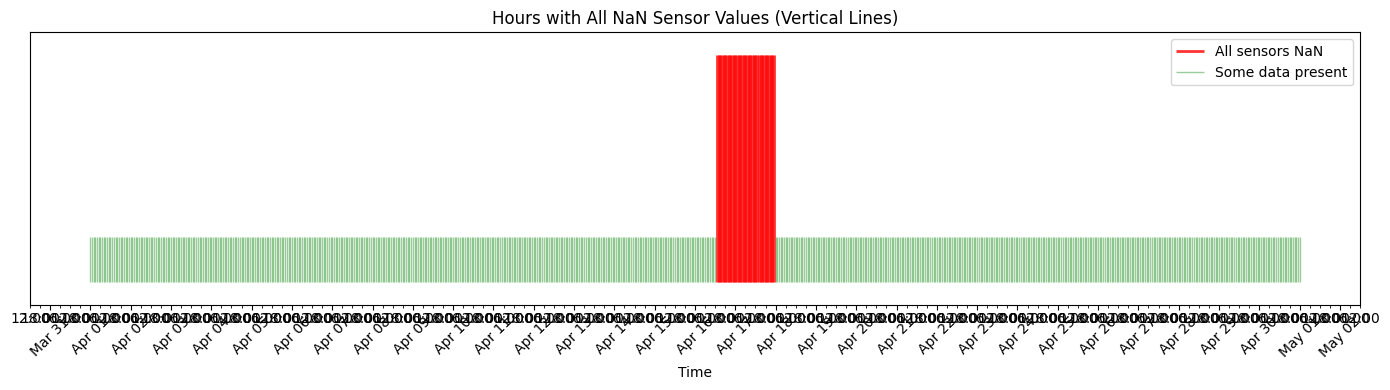

In [49]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

nan_mask = clean_df_hourly[sensor_cols].isna().all(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))  # taller & wider

# Plot all-NaN hours as vertical lines
ax.vlines(
    clean_df_hourly.loc[nan_mask, "time_local"],
    ymin=0, ymax=1,
    color="red", alpha=0.8, linewidth=2, label="All sensors NaN"
)

# Plot hours with some data present
ax.vlines(
    clean_df_hourly.loc[~nan_mask, "time_local"],
    ymin=0, ymax=0.2,
    color="green", alpha=0.4, linewidth=1, label="Some data present"
)

# Formatting
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([])  # hide y-axis ticks
ax.set_title("Hours with All NaN Sensor Values (Vertical Lines)")
ax.set_xlabel("Time")

# Better date formatting: days as major ticks, hours as minor
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
ax.xaxis.set_minor_formatter(mdates.DateFormatter("%H:%M"))

plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

### When do gaps occur? — histograms
By hour‑of‑day (helps spot diurnal patterns): 

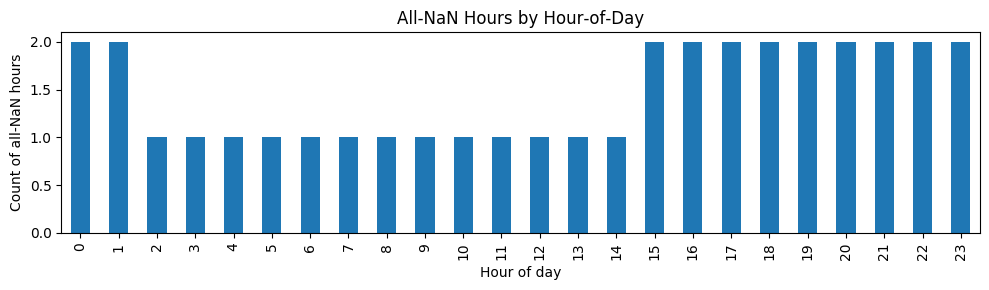

In [50]:
nan_by_hour = nan_rows_df["time_local"].dt.hour.value_counts().sort_index()
ax = nan_by_hour.plot(kind="bar", figsize=(10,3))
ax.set_title("All‑NaN Hours by Hour‑of‑Day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Count of all‑NaN hours")
plt.tight_layout()
plt.show()

By day (helps see clustering by dates): 

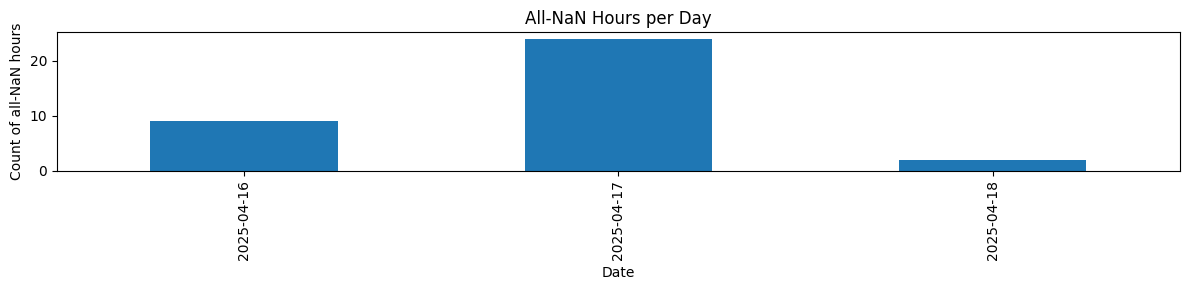

In [52]:
nan_by_day = nan_rows_df["time_local"].dt.date.value_counts().sort_index()
ax = nan_by_day.plot(kind="bar", figsize=(12,3))
ax.set_title("All‑NaN Hours per Day")
ax.set_xlabel("Date")
ax.set_ylabel("Count of all‑NaN hours")
plt.tight_layout()
plt.show()

### Focusing on NaN values under 'Temperature' column

Total hours: 721 | Missing temp hours: 35 (4.85%)
Longest gap: 2025-04-16 15:00:00+02:00 → 2025-04-18 01:00:00+02:00 (35 h)


,_grp,start,end,n_hours
0,2,2025-04-16 15:00:00+02:00,2025-04-18 01:00:00+02:00,35


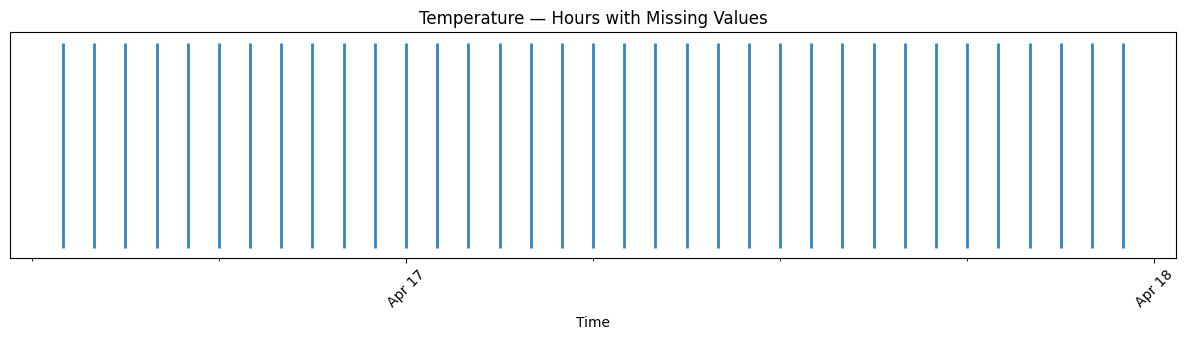

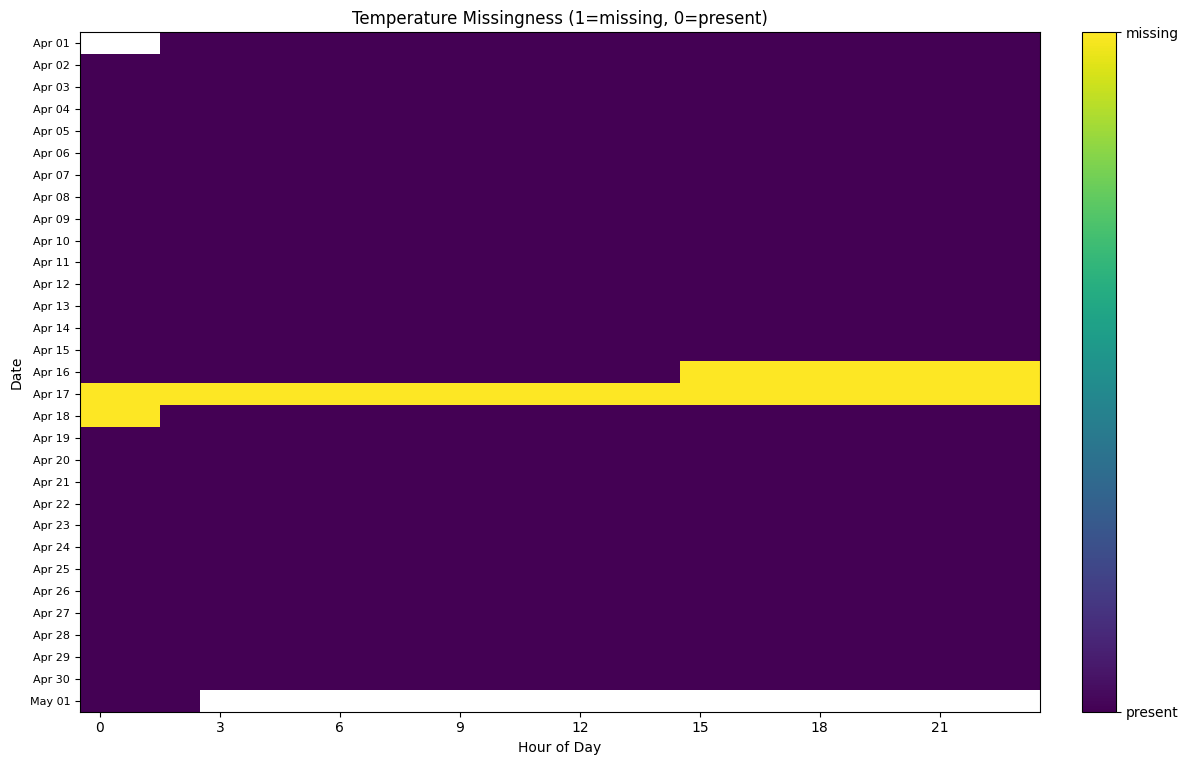

In [55]:
# ==== Temperature gap analysis using clean_df_hourly (expects time_local & temperature) ====

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

dfh = clean_df_hourly[['time_local', 'temperature']].dropna(subset=['time_local']).copy()
dfh = dfh.sort_values('time_local').reset_index(drop=True)

# Mask of missing temperature
temp_na = dfh['temperature'].isna()

# -------- Summary
total_hours = len(dfh)
missing_hours = int(temp_na.sum())
pct_missing = 100.0 * missing_hours / total_hours if total_hours else 0.0
print(f"Total hours: {total_hours} | Missing temp hours: {missing_hours} ({pct_missing:.2f}%)")

# -------- Continuous missing segments (start, end, duration)
grp_id = (temp_na != temp_na.shift()).cumsum()
runs = (
    dfh.assign(_na=temp_na, _grp=grp_id)
       .groupby('_grp', as_index=False)
       .agg(is_na=('_na','first'),
            start=('time_local','first'),
            end=('time_local','last'),
            n_hours=('time_local','size'))
)
gap_runs = runs[runs['is_na']].drop(columns='is_na').reset_index(drop=True)

if not gap_runs.empty:
    longest = gap_runs.iloc[gap_runs['n_hours'].idxmax()]
    print("Longest gap:", longest['start'], "→", longest['end'], f"({int(longest['n_hours'])} h)")
else:
    print("No continuous missing segments.")

display(gap_runs.head(10))

# -------- Visualization A: timeline of missing hours
fig, ax = plt.subplots(figsize=(12, 3.5))
ax.vlines(dfh.loc[temp_na, 'time_local'], ymin=0, ymax=1, linewidth=2, alpha=0.9)
ax.set_ylim(-0.05, 1.05); ax.set_yticks([]); ax.set_title("Temperature — Hours with Missing Values")
ax.set_xlabel("Time")
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_minor_locator(mdates.HourLocator(byhour=[0,6,12,18]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout(); plt.show()

# -------- Visualization B: day×hour heatmap (1=missing, 0=present)
grid = (pd.DataFrame({
            'date': dfh['time_local'].dt.date,
            'hour': dfh['time_local'].dt.hour,
            'is_missing': temp_na.astype(int)
        })
        .groupby(['date','hour'], as_index=False)['is_missing'].max())

pivot = grid.pivot(index='date', columns='hour', values='is_missing').sort_index()

fig, ax = plt.subplots(figsize=(12, max(3, 0.25*len(pivot))))
im = ax.imshow(pivot.values, aspect='auto', interpolation='nearest')
ax.set_title("Temperature Missingness (1=missing, 0=present)")
ax.set_xlabel("Hour of Day"); ax.set_ylabel("Date")
ax.set_xticks(np.arange(0,24,3)); ax.set_xticklabels([str(h) for h in range(0,24,3)])
ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pd.to_datetime(pivot.index).strftime("%b %d"), fontsize=8)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_ticks([0,1]); cbar.set_ticklabels(['present','missing'])
plt.tight_layout(); plt.show()